In [59]:
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.feature_selection import chi2, mutual_info_classif, SelectKBest
from skrebate import ReliefF

import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully!')

Libraries imported successfully!


## Load Preprocessed Dataset (v2)

This dataset was prepared in `data_preparation_v2.ipynb`:
- Source: `Spam.csv`
- Deduplication applied (4601 → ~4210 rows)
- Feature engineering: 57 original + 22 engineered = 79 features
- SMOTE applied for class balancing

In [60]:
df = pd.read_csv('preprocessed_data_v2.csv')
TARGET = 'spam'

print(f'Dataset shape: {df.shape}')
print(f'Class distribution:')
print(df[TARGET].value_counts())
display(df.head())

Dataset shape: (5062, 79)
Class distribution:
spam
1    2531
0    2531
Name: count, dtype: int64


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_present_000,word_present_money,word_present_hp,word_present_hpl,word_present_george,word_present_650,word_present_lab,word_present_labs,word_diversity,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0,0,0,0,0,0,0,0,8,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,1,1,0,0,0,0,0,0,21,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,1,1,0,0,0,0,0,0,24,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0,0,0,0,0,0,0,0,11,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0,0,0,0,0,0,0,0,11,1


In [61]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

feature_names = X.columns.tolist()
print(f'Number of features : {len(feature_names)}')
print(f'  Original (57)    : {[c for c in feature_names if not any(c.startswith(p) for p in ["spam_","ham_","char_spam","char_ham","capital_ratio","word_present","word_diversity"])][:5]}...')
print(f'  Engineered       : {[c for c in feature_names if any(c.startswith(p) for p in ["spam_word","ham_word","spam_ham","char_spam","char_ham","capital_ratio","word_present","word_diversity"])]}')
print(f'Number of samples  : {len(X)}')

Number of features : 78
  Original (57)    : ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our']...
  Engineered       : ['spam_word_score', 'ham_word_score', 'spam_ham_ratio', 'char_spam_score', 'char_ham_score', 'capital_ratio', 'word_present_free', 'word_present_business', 'word_present_email', 'word_present_you', 'word_present_credit', 'word_present_your', 'word_present_000', 'word_present_money', 'word_present_hp', 'word_present_hpl', 'word_present_george', 'word_present_650', 'word_present_lab', 'word_present_labs', 'word_diversity']
Number of samples  : 5062


## Train-Test Split

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

print(f'Training set: {X_train.shape}')
print(f'Testing set : {X_test.shape}')

Training set: (4049, 78)
Testing set : (1013, 78)


## Feature Selection — 7 Methods

Same methods as v1:
1. **Chi-square** — dependency between features and class
2. **Information Gain** — entropy-based measure
3. **Gain Ratio** — normalized information gain
4. **Symmetrical Uncertainty** — normalized mutual information
5. **Relief** — context-sensitive weighting
6. **OneR** — simple rule-based ranking
7. **Correlation** — Pearson |r| with target

In [63]:
def calculate_entropy(y):
    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return -np.sum(probabilities * np.log2(probabilities + 1e-10))

def information_gain_score(X, y):
    return mutual_info_classif(X, y, random_state=42)

def gain_ratio_score(X, y):
    ig_scores = information_gain_score(X, y)
    gr_scores = []
    for i in range(X.shape[1]):
        feature_entropy = calculate_entropy(X.iloc[:, i])
        gr_scores.append(ig_scores[i] / feature_entropy if feature_entropy > 0 else 0)
    return np.array(gr_scores)

def symmetrical_uncertainty_score(X, y):
    ig_scores = information_gain_score(X, y)
    y_entropy = calculate_entropy(y)
    su_scores = []
    for i in range(X.shape[1]):
        feature_entropy = calculate_entropy(X.iloc[:, i])
        su = 2.0 * ig_scores[i] / (y_entropy + feature_entropy + 1e-10)
        su_scores.append(su)
    return np.array(su_scores)

def correlation_score(X, y):
    return np.array([abs(np.corrcoef(X.iloc[:, i], y)[0, 1]) for i in range(X.shape[1])])

def oner_score(X, y):
    scores = []
    for i in range(X.shape[1]):
        feature = X.iloc[:, i]
        feature_binned = pd.cut(feature, bins=10, labels=False, duplicates='drop') if len(np.unique(feature)) > 10 else feature
        accuracy = 0
        for val in np.unique(feature_binned):
            mask = feature_binned == val
            if mask.sum() > 0:
                most_common_class = y[mask].mode()[0] if len(y[mask].mode()) > 0 else 0
                accuracy += (y[mask] == most_common_class).sum()
        scores.append(accuracy / len(y))
    return np.array(scores)

print('Feature selection functions defined.')

Feature selection functions defined.


In [64]:
# Chi-squared requires non-negative features.
# Clip any negative values (possible in SMOTE synthetic samples for some engineered features)
X_train_chi = X_train.clip(lower=0)
X_test_chi  = X_test.clip(lower=0)

chi2_scores, _ = chi2(X_train_chi, y_train)
print('✓ Chi-square scores calculated')

ig_scores = information_gain_score(X_train, y_train)
print('✓ Information Gain scores calculated')

gr_scores = gain_ratio_score(X_train, y_train)
print('✓ Gain Ratio scores calculated')

su_scores = symmetrical_uncertainty_score(X_train, y_train)
print('✓ Symmetrical Uncertainty scores calculated')

relief = ReliefF(n_neighbors=10, n_features_to_select=len(feature_names))
relief.fit(X_train.values, y_train.values)
relief_scores = relief.feature_importances_
print('✓ Relief scores calculated')

oner_scores = oner_score(X_train, y_train)
print('✓ OneR scores calculated')

corr_scores = correlation_score(X_train, y_train)
print('✓ Correlation scores calculated')

print('\nAll feature selection methods completed!')

✓ Chi-square scores calculated
✓ Information Gain scores calculated
✓ Gain Ratio scores calculated
✓ Symmetrical Uncertainty scores calculated
✓ Relief scores calculated
✓ OneR scores calculated
✓ Correlation scores calculated

All feature selection methods completed!


In [65]:
feature_scores = pd.DataFrame({
    'Feature': feature_names,
    'Chi-square': chi2_scores,
    'InfoGain': ig_scores,
    'GainRatio': gr_scores,
    'SU': su_scores,
    'Relief': relief_scores,
    'OneR': oner_scores,
    'Correlation': corr_scores
})

print('Top 5 features per method:')
for method in ['Chi-square', 'InfoGain', 'GainRatio', 'SU', 'Relief', 'OneR', 'Correlation']:
    top = feature_scores.nlargest(5, method)['Feature'].tolist()
    print(f'  {method:15s}: {top}')

Top 5 features per method:
  Chi-square     : ['spam_ham_ratio', 'capital_run_length_total', 'capital_run_length_longest', 'capital_run_length_average', 'ham_word_score']
  InfoGain       : ['spam_ham_ratio', 'ham_word_score', 'char_spam_score', 'spam_word_score', 'char_freq_exclaim']
  GainRatio      : ['word_present_hpl', 'word_present_hp', 'word_present_george', 'word_present_money', 'word_present_lab']
  SU             : ['word_present_hp', 'word_present_hpl', 'word_present_george', 'word_present_money', 'word_freq_remove']
  Relief         : ['word_diversity', 'word_present_hp', 'word_present_george', 'spam_word_score', 'spam_ham_ratio']
  OneR           : ['spam_word_score', 'word_freq_your', 'word_present_your', 'word_present_hp', 'word_present_free']
  Correlation    : ['spam_word_score', 'word_present_hp', 'ham_word_score', 'spam_ham_ratio', 'word_present_free']


## Select Feature Subsets — 87%, 77%, 70%

In [66]:
def get_top_features(scores, feature_names, percentage):
    n_features = int(len(feature_names) * percentage / 100)
    top_indices = np.argsort(scores)[-n_features:]
    return [feature_names[i] for i in top_indices]

feature_subsets = {}
percentages = [87, 77, 70]

for pct in percentages:
    feature_subsets[pct] = {
        'Chi':      get_top_features(chi2_scores, feature_names, pct),
        'InfoGain': get_top_features(ig_scores, feature_names, pct),
        'GainRatio':get_top_features(gr_scores, feature_names, pct),
        'SU':       get_top_features(su_scores, feature_names, pct),
        'Relief':   get_top_features(relief_scores, feature_names, pct),
        'OneR':     get_top_features(oner_scores, feature_names, pct),
        'Corr':     get_top_features(corr_scores, feature_names, pct)
    }
    print(f'{pct}% of {len(feature_names)} features → {len(feature_subsets[pct]["Chi"])} features selected')

87% of 78 features → 67 features selected
77% of 78 features → 60 features selected
70% of 78 features → 54 features selected


## Classifier Definitions — Same as v1

In [67]:
def train_random_forest(X_tr, y_tr, X_te, y_te):
    start = time.time()
    rf = RandomForestClassifier(n_estimators=10, max_features=4, bootstrap=True, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    t = (time.time() - start) * 1000
    return {'model': rf,
            'train_acc': accuracy_score(y_tr, rf.predict(X_tr)) * 100,
            'test_acc':  accuracy_score(y_te, rf.predict(X_te)) * 100,
            'time_ms': t}

def train_part(X_tr, y_tr, X_te, y_te):
    start = time.time()
    dt = DecisionTreeClassifier(criterion='entropy', splitter='best', random_state=42)
    dt.fit(X_tr, y_tr)
    t = (time.time() - start) * 1000
    return {'model': dt,
            'train_acc': accuracy_score(y_tr, dt.predict(X_tr)) * 100,
            'test_acc':  accuracy_score(y_te, dt.predict(X_te)) * 100,
            'time_ms': t}

def train_xgboost(X_tr, y_tr, X_te, y_te):
    start = time.time()
    xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
    xgb.fit(X_tr, y_tr)
    t = (time.time() - start) * 1000
    return {'model': xgb,
            'train_acc': accuracy_score(y_tr, xgb.predict(X_tr)) * 100,
            'test_acc':  accuracy_score(y_te, xgb.predict(X_te)) * 100,
            'time_ms': t}

def train_naive_bayes(X_tr, y_tr, X_te, y_te):
    start = time.time()
    nb = GaussianNB()
    nb.fit(X_tr, y_tr)
    t = (time.time() - start) * 1000
    return {'model': nb,
            'train_acc': accuracy_score(y_tr, nb.predict(X_tr)) * 100,
            'test_acc':  accuracy_score(y_te, nb.predict(X_te)) * 100,
            'time_ms': t}

def train_svm(X_tr, y_tr, X_te, y_te):
    start = time.time()
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    svm.fit(X_tr, y_tr)
    t = (time.time() - start) * 1000
    return {'model': svm,
            'train_acc': accuracy_score(y_tr, svm.predict(X_tr)) * 100,
            'test_acc':  accuracy_score(y_te, svm.predict(X_te)) * 100,
            'time_ms': t}

print('Classifier functions defined.')

Classifier functions defined.


## Baseline — All Features (v2 Preprocessed)

In [68]:
print('=' * 80)
print('BASELINE (100% features — all 79 engineered features)')
print('=' * 80)

print('Random Forest:')
rf_baseline = train_random_forest(X_train, y_train, X_test, y_test)
print(f'  Training Accuracy: {rf_baseline["train_acc"]:.3f}%')
print(f'  Testing Accuracy:  {rf_baseline["test_acc"]:.3f}%')
print(f'  Training Time:     {rf_baseline["time_ms"]:.0f} ms')

print('\nDecision Tree:')
part_baseline = train_part(X_train, y_train, X_test, y_test)
print(f'  Training Accuracy: {part_baseline["train_acc"]:.3f}%')
print(f'  Testing Accuracy:  {part_baseline["test_acc"]:.3f}%')
print(f'  Training Time:     {part_baseline["time_ms"]:.0f} ms')

print('\nXGBoost:')
xgb_baseline = train_xgboost(X_train, y_train, X_test, y_test)
print(f'  Training Accuracy: {xgb_baseline["train_acc"]:.3f}%')
print(f'  Testing Accuracy:  {xgb_baseline["test_acc"]:.3f}%')
print(f'  Training Time:     {xgb_baseline["time_ms"]:.0f} ms')

print('\nNaive Bayes:')
nb_baseline = train_naive_bayes(X_train, y_train, X_test, y_test)
print(f'  Training Accuracy: {nb_baseline["train_acc"]:.3f}%')
print(f'  Testing Accuracy:  {nb_baseline["test_acc"]:.3f}%')
print(f'  Training Time:     {nb_baseline["time_ms"]:.0f} ms')

print('\nSVM:')
svm_baseline = train_svm(X_train, y_train, X_test, y_test)
print(f'  Training Accuracy: {svm_baseline["train_acc"]:.3f}%')
print(f'  Testing Accuracy:  {svm_baseline["test_acc"]:.3f}%')
print(f'  Training Time:     {svm_baseline["time_ms"]:.0f} ms')

print('\n' + '=' * 80)

BASELINE (100% features — all 79 engineered features)
Random Forest:
  Training Accuracy: 99.654%
  Testing Accuracy:  95.854%
  Training Time:     18 ms

Decision Tree:
  Training Accuracy: 99.975%
  Testing Accuracy:  93.682%
  Training Time:     58 ms

XGBoost:
  Training Accuracy: 99.210%
  Testing Accuracy:  96.644%
  Training Time:     183 ms

Naive Bayes:
  Training Accuracy: 70.585%
  Testing Accuracy:  70.681%
  Training Time:     2 ms

SVM:
  Training Accuracy: 70.314%
  Testing Accuracy:  69.299%
  Training Time:     265 ms



## Feature Selection Experiments — 87%, 77%, 70% Subsets

In [69]:
results = []

for pct in percentages:
    print(f'\n{"="*80}')
    print(f'RESULTS WITH {pct}% FEATURES ({len(feature_subsets[pct]["Chi"])} features)')
    print(f'{"="*80}\n')

    for fs_method in ['Chi', 'InfoGain', 'GainRatio', 'SU', 'Relief', 'OneR', 'Corr']:
        selected = feature_subsets[pct][fs_method]
        X_tr = X_train[selected]
        X_te = X_test[selected]

        rf_r   = train_random_forest(X_tr, y_train, X_te, y_test)
        dt_r   = train_part(X_tr, y_train, X_te, y_test)
        xgb_r  = train_xgboost(X_tr, y_train, X_te, y_test)
        nb_r   = train_naive_bayes(X_tr, y_train, X_te, y_test)
        svm_r  = train_svm(X_tr, y_train, X_te, y_test)

        results.append({
            'FS_Percentage': pct,
            'FS_Method': fs_method,
            'RF_Train_Acc': rf_r['train_acc'], 'RF_Test_Acc': rf_r['test_acc'], 'RF_Time_ms': rf_r['time_ms'],
            'DT_Train_Acc': dt_r['train_acc'], 'DT_Test_Acc': dt_r['test_acc'], 'DT_Time_ms': dt_r['time_ms'],
            'XGB_Train_Acc': xgb_r['train_acc'], 'XGB_Test_Acc': xgb_r['test_acc'], 'XGB_Time_ms': xgb_r['time_ms'],
            'NB_Train_Acc': nb_r['train_acc'], 'NB_Test_Acc': nb_r['test_acc'], 'NB_Time_ms': nb_r['time_ms'],
            'SVM_Train_Acc': svm_r['train_acc'], 'SVM_Test_Acc': svm_r['test_acc'], 'SVM_Time_ms': svm_r['time_ms']
        })

        print(f'{fs_method:12s} | RF: T={rf_r["train_acc"]:.1f}% V={rf_r["test_acc"]:.1f}% | '
              f'DT: T={dt_r["train_acc"]:.1f}% V={dt_r["test_acc"]:.1f}% | '
              f'XGB: T={xgb_r["train_acc"]:.1f}% V={xgb_r["test_acc"]:.1f}% | '
              f'NB: T={nb_r["train_acc"]:.1f}% V={nb_r["test_acc"]:.1f}% | '
              f'SVM: T={svm_r["train_acc"]:.1f}% V={svm_r["test_acc"]:.1f}%')

print('\n' + '='*80)
print('All experiments completed!')
print('='*80)


RESULTS WITH 87% FEATURES (67 features)

Chi          | RF: T=99.7% V=95.3% | DT: T=100.0% V=92.2% | XGB: T=99.2% V=96.2% | NB: T=70.6% V=70.7% | SVM: T=70.3% V=69.3%
InfoGain     | RF: T=99.7% V=95.6% | DT: T=100.0% V=93.3% | XGB: T=99.2% V=96.2% | NB: T=70.6% V=70.7% | SVM: T=70.3% V=69.3%
GainRatio    | RF: T=99.7% V=94.9% | DT: T=100.0% V=93.5% | XGB: T=99.0% V=96.5% | NB: T=70.2% V=69.3% | SVM: T=70.3% V=69.3%
SU           | RF: T=99.7% V=94.6% | DT: T=100.0% V=92.8% | XGB: T=99.2% V=96.4% | NB: T=70.6% V=70.7% | SVM: T=70.3% V=69.3%
Relief       | RF: T=99.7% V=95.1% | DT: T=100.0% V=93.0% | XGB: T=99.2% V=96.3% | NB: T=70.6% V=70.7% | SVM: T=70.3% V=69.3%
OneR         | RF: T=99.7% V=95.5% | DT: T=100.0% V=92.7% | XGB: T=98.9% V=96.2% | NB: T=72.0% V=72.5% | SVM: T=70.3% V=69.3%
Corr         | RF: T=99.6% V=95.3% | DT: T=100.0% V=93.5% | XGB: T=99.1% V=96.4% | NB: T=71.2% V=71.4% | SVM: T=70.3% V=69.3%

RESULTS WITH 77% FEATURES (60 features)

Chi          | RF: T=99.6% V=95.0%

## Export Results

In [70]:
results_df = pd.DataFrame(results)

algorithms_info = {
    'RF':  ('Random Forest', 'RF_Test_Acc',  'RF_Train_Acc',  'RF_Time_ms',  rf_baseline),
    'DT':  ('Decision Tree', 'DT_Test_Acc',  'DT_Train_Acc',  'DT_Time_ms',  part_baseline),
    'XGB': ('XGBoost',       'XGB_Test_Acc', 'XGB_Train_Acc', 'XGB_Time_ms', xgb_baseline),
    'NB':  ('Naive Bayes',   'NB_Test_Acc',  'NB_Train_Acc',  'NB_Time_ms',  nb_baseline),
    'SVM': ('SVM',           'SVM_Test_Acc', 'SVM_Train_Acc', 'SVM_Time_ms', svm_baseline)
}

overall_best_by_alg = {}
for alg_code, (alg_name, test_col, train_col, time_col, baseline) in algorithms_info.items():
    best_fs_idx = results_df[test_col].idxmax()
    best_fs = results_df.loc[best_fs_idx]
    if best_fs[test_col] > baseline['test_acc']:
        overall_best_by_alg[alg_code] = {
            'name': alg_name, 'test': best_fs[test_col], 'train': best_fs[train_col],
            'time': best_fs[time_col], 'pct': best_fs['FS_Percentage'], 'method': best_fs['FS_Method']
        }
    else:
        overall_best_by_alg[alg_code] = {
            'name': alg_name, 'test': baseline['test_acc'], 'train': baseline['train_acc'],
            'time': baseline['time_ms'], 'pct': 100, 'method': 'Baseline (all features)'
        }

all_best_list = sorted(overall_best_by_alg.values(), key=lambda x: x['test'], reverse=True)

results_df.to_csv('v2_spam_classification_results.csv', index=False)
feature_scores.to_csv('v2_feature_scores.csv', index=False)
print("Results saved to 'v2_spam_classification_results.csv'")
print("Feature scores saved to 'v2_feature_scores.csv'")

Results saved to 'v2_spam_classification_results.csv'
Feature scores saved to 'v2_feature_scores.csv'


## v1 vs v2 — Result Comparison

In [71]:
# v1 baseline results (from v1_spamclassification_baseline.ipynb)
v1_baseline = {
    'RF':  {'train': 99.620, 'test': 93.268},
    'DT':  {'train': 99.973, 'test': 91.965},
    'XGB': {'train': 98.342, 'test': 94.680},
    'NB':  {'train': 82.255, 'test': 83.388},
    'SVM': {'train': 71.603, 'test': 70.575}
}

# v1 best-with-FS results
v1_best_with_fs = {
    'RF':  {'test': 94.46, 'pct': 87, 'method': 'Corr'},
    'DT':  {'test': 92.83, 'pct': 77, 'method': 'GainRatio'},
    'XGB': {'test': 95.01, 'pct': 87, 'method': 'OneR'},
    'NB':  {'test': 86.32, 'pct': 77, 'method': 'OneR'},
    'SVM': {'test': 73.18, 'pct': 77, 'method': 'GainRatio'}
}

print('=' * 120)
print('RESULT COMPARISON: v1 (raw Spam.csv) vs v2 (preprocessed + feature engineering + SMOTE)')
print('=' * 120)
print(f'{"Classifier":<15} {"v1 Baseline":>12} {"v1 Best FS":>12} {"v2 Best Overall":>16} {"Delta (v2-v1base)":>18} {"v2 Best Config":>22}')
print('-' * 120)

for alg_code, alg_name in [('RF','Random Forest'),('DT','Decision Tree'),('XGB','XGBoost'),('NB','Naive Bayes'),('SVM','SVM')]:
    v1_base   = v1_baseline[alg_code]['test']
    v1_best   = v1_best_with_fs[alg_code]['test']
    v2_best   = overall_best_by_alg[alg_code]['test']
    delta     = v2_best - v1_base
    delta_str = f"+{delta:.2f}%" if delta >= 0 else f"{delta:.2f}%"
    config    = f'{overall_best_by_alg[alg_code]["pct"]}% {overall_best_by_alg[alg_code]["method"]}'
    print(f'{alg_name:<15} {v1_base:>12.2f}% {v1_best:>12.2f}% {v2_best:>16.2f}% {delta_str:>18} {config:>22}')

print('=' * 120)
print('Note: v2 Best Overall = best result across (100% baseline, 87%, 77%, 70% FS subsets)')


RESULT COMPARISON: v1 (raw Spam.csv) vs v2 (preprocessed + feature engineering + SMOTE)
Classifier       v1 Baseline   v1 Best FS  v2 Best Overall  Delta (v2-v1base)         v2 Best Config
------------------------------------------------------------------------------------------------------------------------
Random Forest          93.27%        94.46%            96.15%             +2.88%               77% Corr
Decision Tree          91.97%        92.83%            93.68%             +1.72% 100% Baseline (all features)
XGBoost                94.68%        95.01%            96.74%             +2.06%          70% GainRatio
Naive Bayes            83.39%        86.32%            72.46%            -10.93%               87% OneR
SVM                    70.58%        73.18%            69.30%             -1.28% 100% Baseline (all features)
Note: v2 Best Overall = best result across (100% baseline, 87%, 77%, 70% FS subsets)


In [72]:
print('\n' + '=' * 100)
print('CONCLUSION — v2 (Preprocessed Data with Feature Engineering + SMOTE)')
print('=' * 100)
print(f'\nDataset: preprocessed_data_v2.csv')
print(f'  Original features : 57')
print(f'  Engineered features: {len(feature_names) - 57}')
print(f'  Total features    : {len(feature_names)}')
print(f'  SMOTE balancing   : Yes')
print()
print('v2 Baseline (100% features):')
for alg_code, (alg_name, test_col, train_col, time_col, baseline) in algorithms_info.items():
    print(f'  {alg_name:15s}: Test={baseline["test_acc"]:.2f}%  Train={baseline["train_acc"]:.2f}%')

print()
print('v2 Best per algorithm (across all FS methods and percentages):')
for alg_code in ['RF', 'DT', 'XGB', 'NB', 'SVM']:
    res = overall_best_by_alg[alg_code]
    print(f'  {res["name"]:15s}: {res["test"]:.2f}% ({res["pct"]}% features via {res["method"]})')

print()
print(f'🏆 Overall best v2 classifier: {all_best_list[0]["name"]} — {all_best_list[0]["test"]:.2f}%')
print('=' * 100)


CONCLUSION — v2 (Preprocessed Data with Feature Engineering + SMOTE)

Dataset: preprocessed_data_v2.csv
  Original features : 57
  Engineered features: 21
  Total features    : 78
  SMOTE balancing   : Yes

v2 Baseline (100% features):
  Random Forest  : Test=95.85%  Train=99.65%
  Decision Tree  : Test=93.68%  Train=99.98%
  XGBoost        : Test=96.64%  Train=99.21%
  Naive Bayes    : Test=70.68%  Train=70.59%
  SVM            : Test=69.30%  Train=70.31%

v2 Best per algorithm (across all FS methods and percentages):
  Random Forest  : 96.15% (77% features via Corr)
  Decision Tree  : 93.68% (100% features via Baseline (all features))
  XGBoost        : 96.74% (70% features via GainRatio)
  Naive Bayes    : 72.46% (87% features via OneR)
  SVM            : 69.30% (100% features via Baseline (all features))

🏆 Overall best v2 classifier: XGBoost — 96.74%


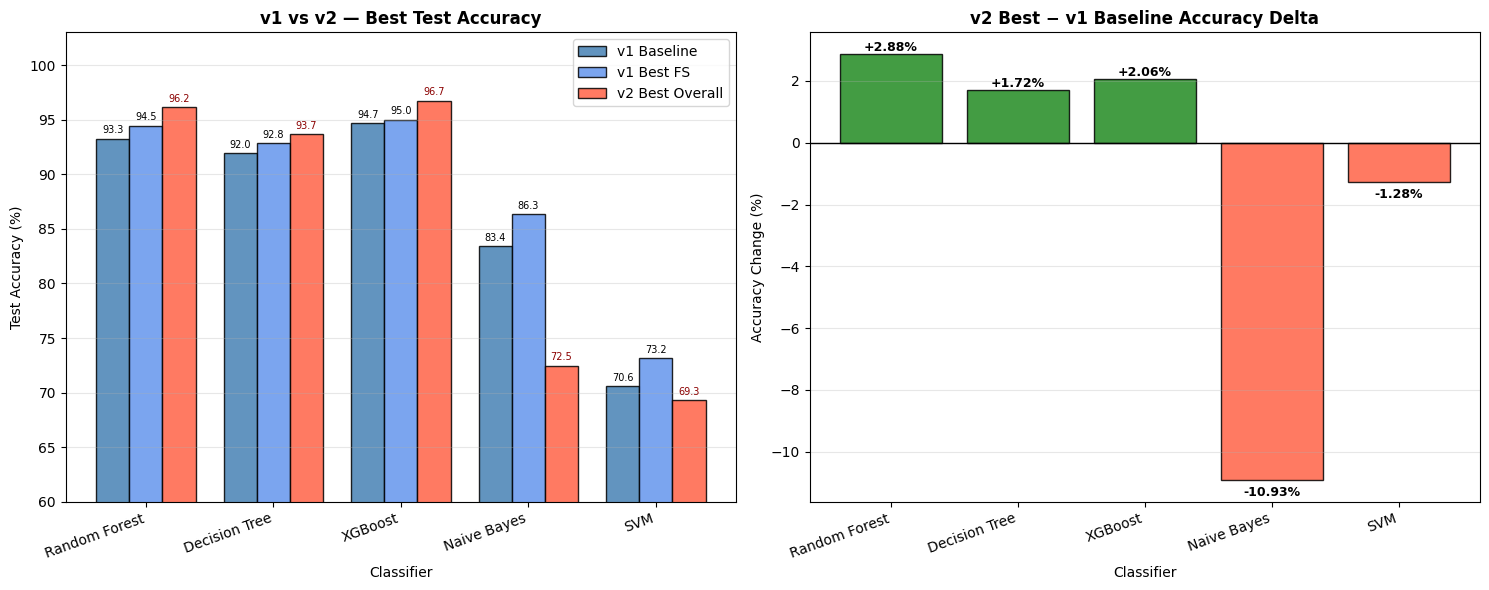

Comparison plot saved as v1_vs_v2_comparison.png


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

classifiers = ['Random Forest', 'Decision Tree', 'XGBoost', 'Naive Bayes', 'SVM']
alg_keys    = ['RF', 'DT', 'XGB', 'NB', 'SVM']

v1_base_tests = [v1_baseline[k]['test'] for k in alg_keys]
v1_fs_tests   = [v1_best_with_fs[k]['test'] for k in alg_keys]
v2_tests      = [overall_best_by_alg[k]['test'] for k in alg_keys]

x = np.arange(len(classifiers))
width = 0.26

bars1 = axes[0].bar(x - width, v1_base_tests, width, label='v1 Baseline', color='steelblue', alpha=0.85, edgecolor='black')
bars2 = axes[0].bar(x,         v1_fs_tests,   width, label='v1 Best FS',   color='cornflowerblue', alpha=0.85, edgecolor='black')
bars3 = axes[0].bar(x + width, v2_tests,      width, label='v2 Best Overall', color='tomato', alpha=0.85, edgecolor='black')

axes[0].set_xlabel('Classifier')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('v1 vs v2 — Best Test Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classifiers, rotation=20, ha='right')
axes[0].legend()
axes[0].set_ylim(60, 103)
axes[0].grid(axis='y', alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)
for bar in bars3:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7, color='darkred')

deltas = [v2 - v1 for v1, v2 in zip(v1_base_tests, v2_tests)]
colors = ['forestgreen' if d >= 0 else 'tomato' for d in deltas]
axes[1].bar(classifiers, deltas, color=colors, edgecolor='black', alpha=0.85)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Classifier')
axes[1].set_ylabel('Accuracy Change (%)')
axes[1].set_title('v2 Best − v1 Baseline Accuracy Delta', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(classifiers)))
axes[1].set_xticklabels(classifiers, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for i, (clf, d) in enumerate(zip(classifiers, deltas)):
    axes[1].text(i, d + (0.1 if d >= 0 else -0.5), f'{d:+.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('v1_vs_v2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison plot saved as v1_vs_v2_comparison.png')


## Detailed Results Table by Feature Percentage

In [74]:
print('\n' + '='*100)
print('DETAILED PERFORMANCE BY FEATURE PERCENTAGE (v2)')
print('='*100)

for alg_code, (alg_name, test_col, train_col, time_col, baseline) in algorithms_info.items():
    print(f'\n📊 {alg_name}:')
    print(f'  100% Features (all {len(feature_names)}): Test={baseline["test_acc"]:.2f}% | Train={baseline["train_acc"]:.2f}% | Time={baseline["time_ms"]:.0f}ms (Baseline)')
    for pct in [87, 77, 70]:
        pct_results = results_df[results_df['FS_Percentage'] == pct]
        best_idx = pct_results[test_col].idxmax()
        best_row = pct_results.loc[best_idx]
        print(f'  {pct}% Features: Test={best_row[test_col]:.2f}% | Train={best_row[train_col]:.2f}% | '
              f'Time={best_row[time_col]:.0f}ms (Best: {best_row["FS_Method"]})')
    res = overall_best_by_alg[alg_code]
    print(f'  🏆 Overall Best: {res["test"]:.2f}% — {res["pct"]}% features with {res["method"]}')

print('\n' + '='*100)
print(f'🏆 OVERALL BEST v2 CLASSIFIER: {all_best_list[0]["name"]}')
print(f'    Test Accuracy : {all_best_list[0]["test"]:.2f}%')
print(f'    Configuration : {all_best_list[0]["pct"]}% features with {all_best_list[0]["method"]}')
print('='*100)


DETAILED PERFORMANCE BY FEATURE PERCENTAGE (v2)

📊 Random Forest:
  100% Features (all 78): Test=95.85% | Train=99.65% | Time=18ms (Baseline)
  87% Features: Test=95.56% | Train=99.73% | Time=16ms (Best: InfoGain)
  77% Features: Test=96.15% | Train=99.68% | Time=14ms (Best: Corr)
  70% Features: Test=95.26% | Train=99.75% | Time=13ms (Best: InfoGain)
  🏆 Overall Best: 96.15% — 77% features with Corr

📊 Decision Tree:
  100% Features (all 78): Test=93.68% | Train=99.98% | Time=58ms (Baseline)
  87% Features: Test=93.48% | Train=99.98% | Time=31ms (Best: GainRatio)
  77% Features: Test=93.39% | Train=99.98% | Time=33ms (Best: Relief)
  70% Features: Test=93.29% | Train=99.98% | Time=34ms (Best: InfoGain)
  🏆 Overall Best: 93.68% — 100% features with Baseline (all features)

📊 XGBoost:
  100% Features (all 78): Test=96.64% | Train=99.21% | Time=183ms (Baseline)
  87% Features: Test=96.54% | Train=98.96% | Time=173ms (Best: GainRatio)
  77% Features: Test=96.64% | Train=99.09% | Time=153